# Week 4 Day 2 — Core Supervised Learning
## Preprocessing, EDA, Models & Evaluation
**Dataset:** UCI "Adult" (Census Income) — same data and hold-out test set as Day 1

**Author:** Umer Sahi | CM-IT Batch 2

---

## Setup & Recap of Day 1

We reload the data and recreate the **exact same** stratified train/dev/test split from Day 1
(same `random_state=42`, same split logic), so today's models are evaluated on the identical
hold-out test set as the Day 1 baselines. This is what makes the Day 1 vs Day 2 comparison later
in this notebook valid — comparing scores computed on different test sets would not be a fair
comparison.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
import joblib

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
np.random.seed(RANDOM_STATE)

In [ ]:
COLS = ['age','workclass','fnlwgt','education','education_num','marital_status',
        'occupation','relationship','race','sex','capital_gain','capital_loss',
        'hours_per_week','native_country','income']


from sklearn.datasets import fetch_openml
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame.copy()
print("Loaded via sklearn.datasets.fetch_openml")

Loaded via sklearn.datasets.fetch_openml


In [ ]:
df.columns = [c.replace('-', '_') for c in df.columns]
df = df.rename(columns={'class': 'income'})

In [ ]:
df = df.replace('?', np.nan)

In [ ]:
df['income'] = df['income'].astype(str).str.strip().str.rstrip('.')
for c in df.select_dtypes(include='category').columns:
        df[c] = df[c].astype(object)

In [ ]:
df['target'] = (df['income'] == '>50K').astype(int)
print("Shape:", df.shape)

Shape: (48842, 16)


In [ ]:
# --- Recreate Day 1's exact split ---
train_full, test = train_test_split(
    df, test_size=0.20, stratify=df['target'], random_state=RANDOM_STATE
)
train, dev = train_test_split(
    train_full, test_size=0.125, stratify=train_full['target'], random_state=RANDOM_STATE
)

print(f"train: {train.shape}  dev: {dev.shape}  test: {test.shape}")
print(f"train positive rate: {train['target'].mean():.4f}  test positive rate: {test['target'].mean():.4f}")

train: (34188, 16)  dev: (4885, 16)  test: (9769, 16)
train positive rate: 0.2393  test positive rate: 0.2393


---
## Expanded EDA for Preprocessing Decisions

Day 1's EDA covered the overall shape of the data. Before building the preprocessing pipeline,
we dig one level deeper into exactly the properties that *drive* our preprocessing choices:
how skewed the numeric features are (imputation strategy), how many categories each categorical
feature has (encoding strategy/risk), how numeric features correlate with each other and the
target, and how the target rate varies across key categories. All of this analysis uses the
**training set only**, so the hold-out test set stays untouched.

In [ ]:
# --- Skewness of numeric features: justifies median vs. mean imputation ---
numeric_features_check = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
skew_table = train[numeric_features_check].skew().sort_values(ascending=False).rename('skewness')
print("Skewness of numeric features (train set):")
print(skew_table.round(2))
print("\nRule of thumb: |skew| > 1 is highly skewed. capital_gain and capital_loss are extremely")
print("skewed -- this is the concrete evidence behind choosing median (not mean) imputation.")

Skewness of numeric features (train set):
capital_gain      12.13
capital_loss       4.50
age                0.54
hours_per_week     0.25
education_num     -0.30
Name: skewness, dtype: float64

Rule of thumb: |skew| > 1 is highly skewed. capital_gain and capital_loss are extremely
skewed -- this is the concrete evidence behind choosing median (not mean) imputation.


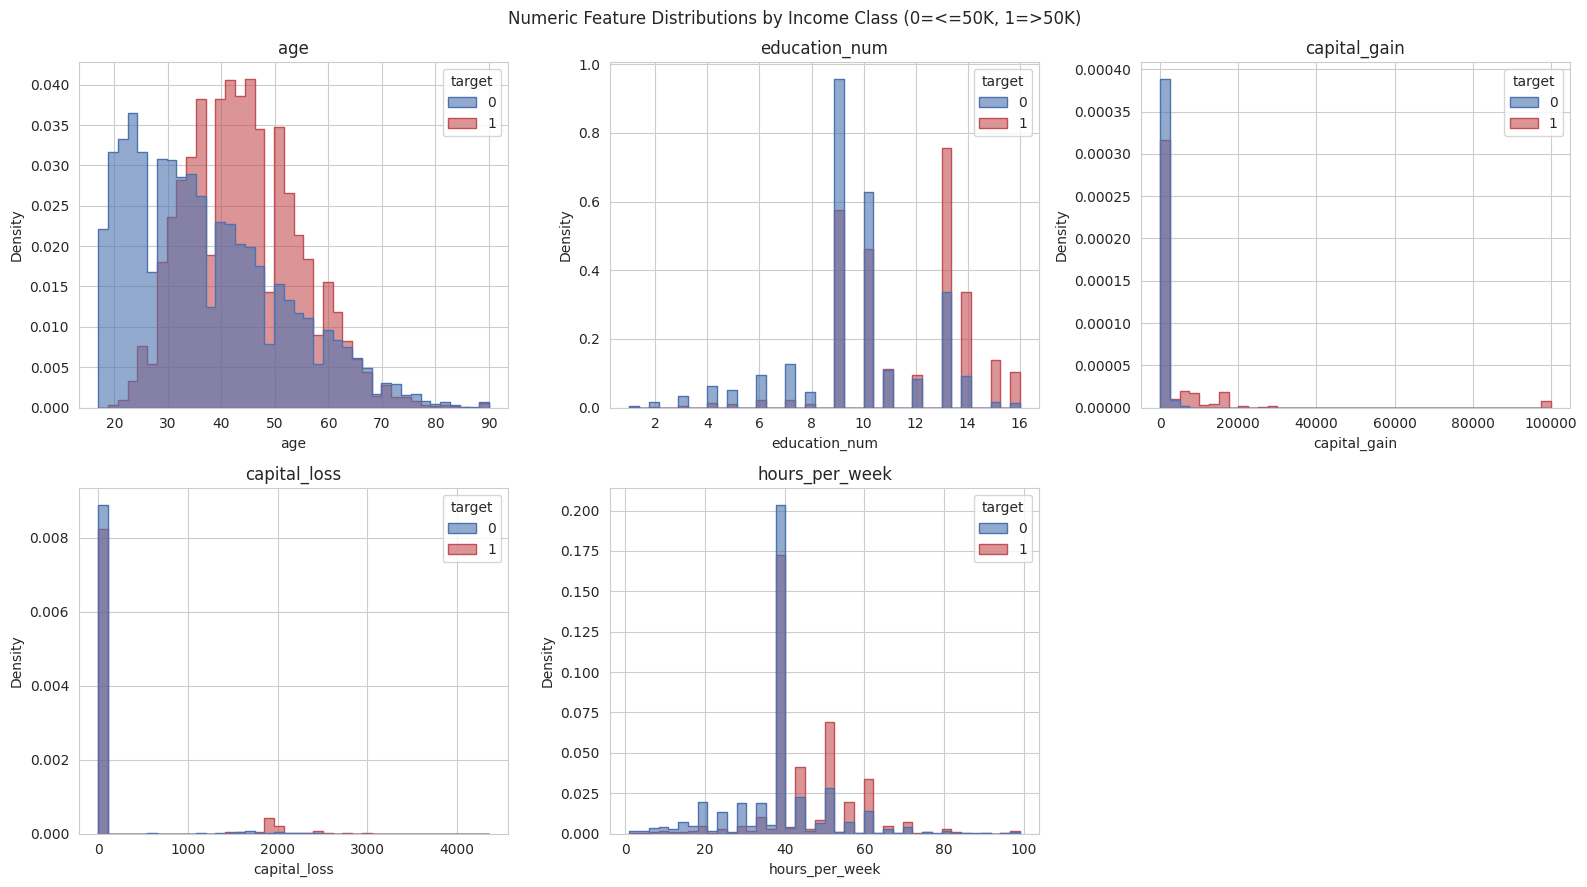

In [ ]:
# --- Distributions of numeric features, split by target class ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), numeric_features_check):
    sns.histplot(data=train, x=col, hue='target', bins=40, ax=ax,
                 palette=['#4C72B0', '#C44E52'], alpha=0.6, element='step', stat='density', common_norm=False)
    ax.set_title(col)
    ax.set_xlabel(col) # Explicitly setting x-label
    ax.set_ylabel('Density') # Explicitly setting y-label
axes.ravel()[-1].axis('off')
plt.suptitle('Numeric Feature Distributions by Income Class (0=<=50K, 1=>50K)')
plt.tight_layout()
plt.show()

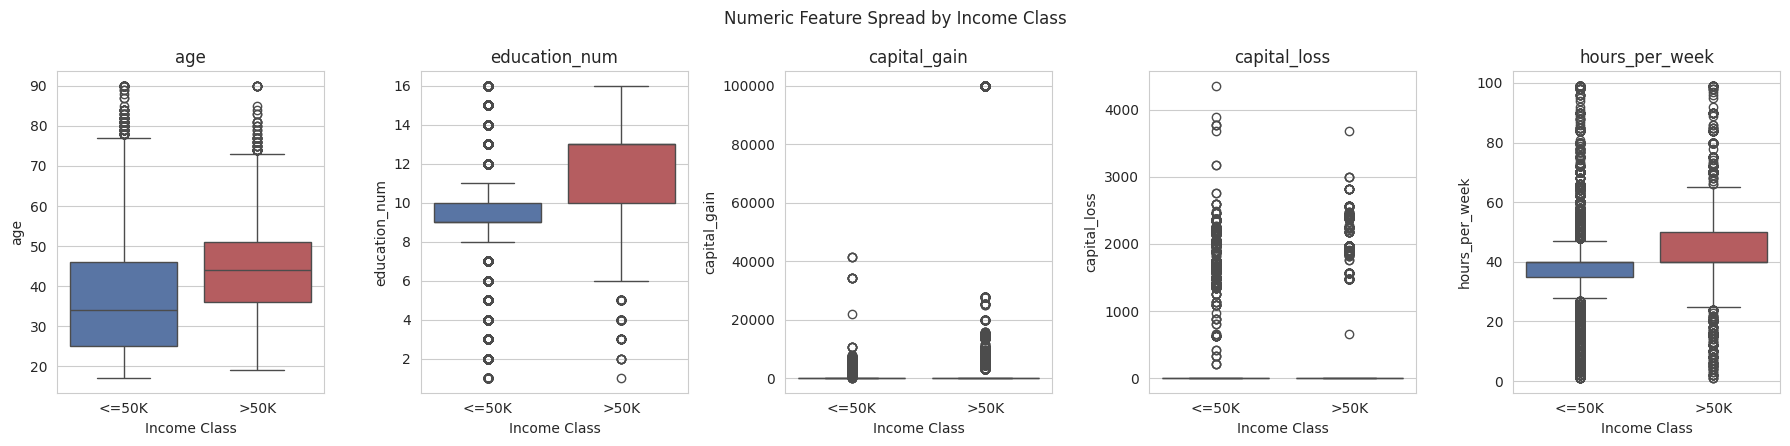

In [ ]:
# --- Boxplots: numeric features vs target, for outlier/scale intuition ---
fig, axes = plt.subplots(1, 5, figsize=(18, 4.5))
for ax, col in zip(axes, numeric_features_check):
    sns.boxplot(data=train, x='target', y=col, ax=ax, palette=['#4C72B0', '#C44E52'], hue='target', legend=False)
    ax.set_xticks([0, 1]) # Explicitly set tick locations
    ax.set_xticklabels(['<=50K', '>50K'])
    ax.set_xlabel('Income Class') # Explicitly set x-label
    ax.set_title(col)
plt.suptitle('Numeric Feature Spread by Income Class')
plt.tight_layout()
plt.show()

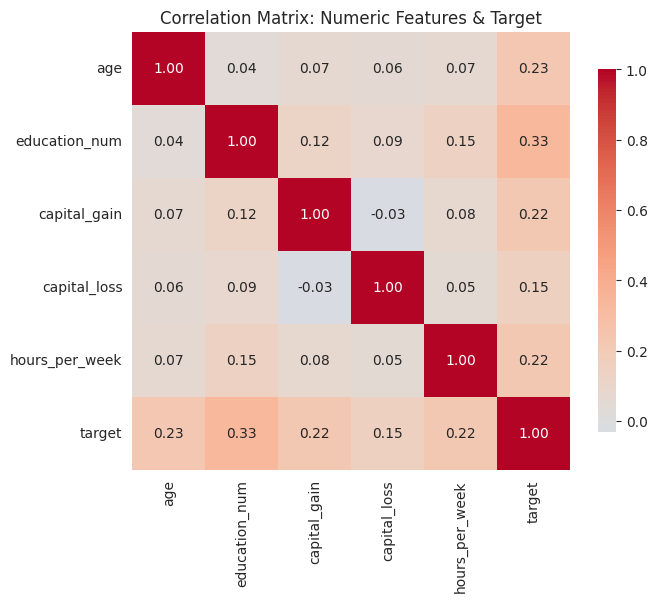

Strongest single-feature correlations with target:
education_num     0.334
age               0.229
hours_per_week    0.224
capital_gain      0.221
capital_loss      0.153
Name: target, dtype: float64


In [ ]:
# --- Correlation heatmap: numeric features + target ---
corr = train[numeric_features_check + ['target']].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix: Numeric Features & Target')
plt.tight_layout()
plt.show()

print("Strongest single-feature correlations with target:")
print(corr['target'].drop('target').abs().sort_values(ascending=False).round(3))

In [ ]:
# --- Cardinality of categorical features: informs one-hot encoding risk ---
categorical_features_check = ['workclass', 'education', 'marital_status', 'occupation',
                               'relationship', 'race', 'sex', 'native_country']
cardinality = train[categorical_features_check].nunique().sort_values(ascending=False)
print("Number of unique categories per categorical feature (train set):")
print(cardinality)
print()
print("native_country has by far the highest cardinality (40 categories) -- one-hot encoding it")
print("as-is produces 40 sparse columns, most representing a handful of rows each. This is flagged")
print("again in Task 5 as a candidate change (grouping rare countries into 'Other').")

Number of unique categories per categorical feature (train set):
native_country    41
education         16
occupation        14
workclass          8
marital_status     7
relationship       6
race               5
sex                2
dtype: int64

native_country has by far the highest cardinality (40 categories) -- one-hot encoding it
as-is produces 40 sparse columns, most representing a handful of rows each. This is flagged
again in Task 5 as a candidate change (grouping rare countries into 'Other').


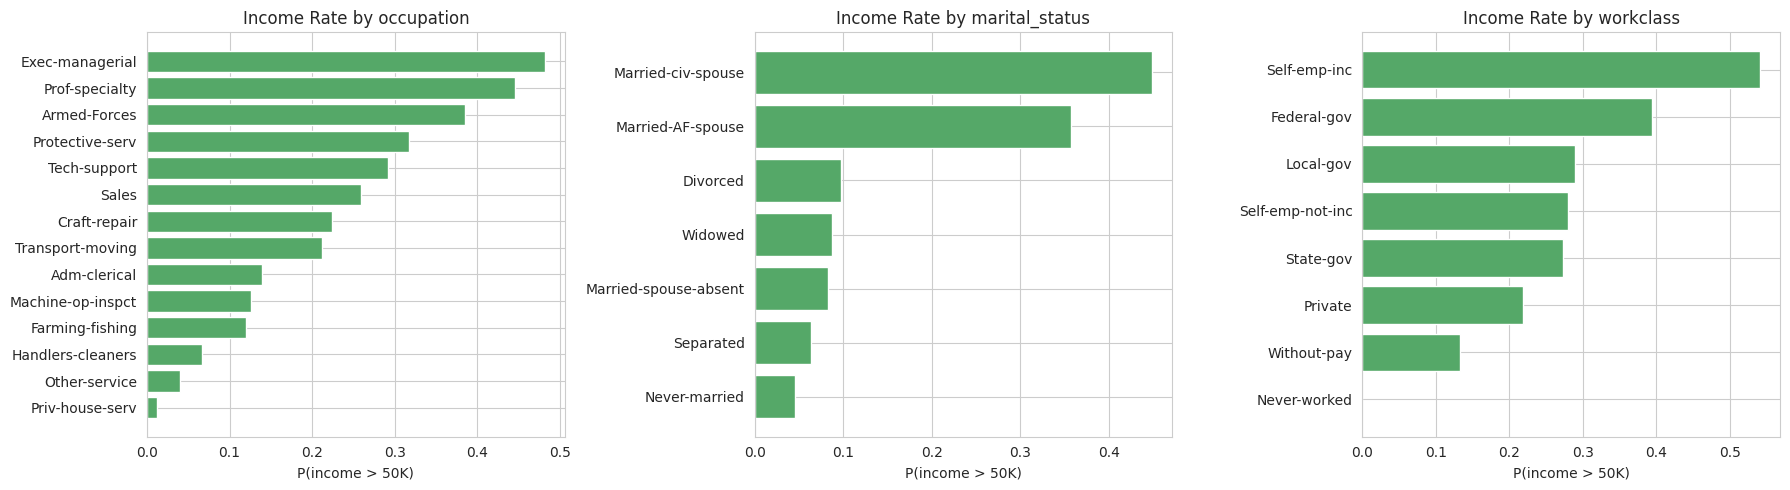

In [ ]:
# --- Target rate by category, for a few features with clear business relevance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['occupation', 'marital_status', 'workclass']):
    rate = train.groupby(col)['target'].mean().sort_values()
    ax.barh(rate.index, rate.values, color='#55A868')
    ax.set_xlabel('P(income > 50K)')
    ax.set_title(f'Income Rate by {col}')
plt.tight_layout()
plt.show()

**What this EDA tells us, concretely:**
- `capital_gain` (skew ≈ 12) and `capital_loss` (skew ≈ 4.6) are extremely right-skewed and
  zero-inflated — strong, measured justification for **median** imputation over mean.
- `education_num` has the strongest single-feature correlation with the target among numeric
  features, consistent with it being the top Decision Tree split and a top Logistic Regression
  coefficient later in this notebook.
- `native_country` (40 categories) is a real one-hot encoding risk — flagged here and revisited
  in the Day 3 planning section.
- The target-rate-by-category charts make the "why OneHotEncoder, not ordinal" decision visual:
  categories like `occupation` and `marital_status` have no natural order, and their income rates
  don't follow any ranking that an ordinal encoding could capture correctly.

---
## Task 1: Preprocessing Plan & Implementation

**Feature lists**

We deliberately **exclude two columns** identified as issues in Day 1's error analysis, rather than
feeding them in raw:
- **`fnlwgt`** — a census sampling weight describing how many people in the population a row
  represents, not a real attribute of the individual. It's also nearly a unique identifier per row,
  which is a known way to make tree-based models overfit by memorizing individual training rows
  instead of learning generalizable patterns.
- **`education`** (string) — redundant with `education_num` (the same information as an ordered
  integer). Keeping both would create perfectly collinear features for no benefit.

Missing values (`'?'`) were already converted to `NaN` during loading (Day 1), so no further
`'?'`-handling is needed here — confirmed below.

In [ ]:
numeric_features = ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
categorical_features = ['workclass', 'marital_status', 'occupation', 'relationship',
                         'race', 'sex', 'native_country']

X_train = train[numeric_features + categorical_features]
y_train = train['target']
X_dev = dev[numeric_features + categorical_features]
y_dev = dev['target']
X_test = test[numeric_features + categorical_features]
y_test = test['target']

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print()
print("Confirming '?' was already converted to NaN (no literal '?' strings remain):")
print((X_train == '?').sum().sum(), "literal '?' values found")
print()
print("Missing values in training features:")
print(X_train.isna().sum()[X_train.isna().sum() > 0])

Numeric features: ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical features: ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Confirming '?' was already converted to NaN (no literal '?' strings remain):
0 literal '?' values found

Missing values in training features:
workclass         1970
occupation        1979
native_country     587
dtype: int64


**Building the `ColumnTransformer` pipeline**

- **Numeric pipeline: median imputation → StandardScaler.**
  Median (not mean) imputation was chosen because the EDA above measured `capital_gain` and
  `capital_loss` as extremely skewed and zero-inflated — the mean would be pulled toward the long
  tail and produce an unrealistic "typical" value, while the median stays robust to those outliers.
  Scaling is required afterward because Logistic Regression is distance/gradient based and features
  on very different scales (e.g. `age` in tens vs `capital_gain` in thousands) would otherwise
  dominate the model's coefficients for reasons unrelated to actual importance.
  *Alternative considered and skipped:* mean imputation — skipped for the skew reason above.

- **Categorical pipeline: most-frequent imputation → `OneHotEncoder(handle_unknown='ignore')`.**
  Most-frequent imputation is a simple, safe default for the categorical missingness here (a few
  percent per column). One-hot encoding was chosen because none of these categorical features have a
  natural order — confirmed visually in the EDA target-rate charts above, where income rate doesn't
  follow any consistent ranking across categories. An ordinal encoder would incorrectly imply such a
  ranking. `handle_unknown='ignore'` protects the pipeline from breaking if the test set (or future
  data) contains a category value not seen during training.
  *Alternatives considered and skipped:* ordinal encoding — skipped because there's no meaningful
  order to these categories; target encoding — skipped because it requires careful cross-validation
  to avoid leaking target information into the encoded feature, which is unnecessary complexity for
  today's baseline models; dropping rows with missing categoricals — skipped because it would discard
  ~7% of the data unnecessarily when a simple imputer works fine.

In [ ]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'education_num', 'capital_gain',
                                  'capital_loss', 'hours_per_week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'marital_status', 'occupation',
                                  'relationship', 'race', 'sex',
                                  'native_country'])])

---
## Task 2: Train Two Supervised Models (in Pipelines)

Both models are wrapped in a single `Pipeline` with the `ColumnTransformer` above, so preprocessing
is fit **only on training data** in both cases — no statistics (median, most-frequent category,
scaler mean/std, one-hot categories) are ever computed using the test set. This is what prevents
data leakage: the same `.fit()` call fits the preprocessor and the model together, and only
`X_train`/`y_train` are passed in.

- **Logistic Regression:** `solver='lbfgs'` (default), which supports L2 regularization
  (`penalty='l2'`, the default) — this is the "solver that supports regularization" requirement.
  `max_iter=1000` is set because one-hot encoding produces many features and the default 100
  iterations can fail to converge.
- **Decision Tree Classifier:** left at default (unrestricted) depth intentionally, so Task 4 can
  show and discuss real overfitting behavior on train vs. test scores.

Both use `random_state=42` for reproducibility.

In [ ]:
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver='lbfgs'))
])

tree_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

# Fit on TRAINING SET ONLY -- the hold-out test set is not touched in this step.
logreg_pipe.fit(X_train, y_train)
tree_pipe.fit(X_train, y_train)

print("Logistic Regression fitted.")
print("Decision Tree fitted.")

Logistic Regression fitted.
Decision Tree fitted.


**Early overfitting check using the dev set**

Before ever touching the hold-out test set, we do a quick train-vs-dev accuracy check. This is a
cheap early warning: if a model already shows a large train/dev gap here, we know to expect
overfitting before we've spent our one look at the true test set.

In [ ]:
log_train_acc = logreg_pipe.score(X_train, y_train)
log_dev_acc = logreg_pipe.score(X_dev, y_dev)
tree_train_acc = tree_pipe.score(X_train, y_train)
tree_dev_acc = tree_pipe.score(X_dev, y_dev)

dev_check = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Train Accuracy': [log_train_acc, tree_train_acc],
    'Dev Accuracy': [log_dev_acc, tree_dev_acc],
})
dev_check['Train - Dev Gap'] = dev_check['Train Accuracy'] - dev_check['Dev Accuracy']
dev_check.round(4)

,Model,Train Accuracy,Dev Accuracy,Train - Dev Gap
0,Logistic Regression,0.8512,0.8532,-0.0020
1,Decision Tree,0.9750,0.8207,0.1544


In [ ]:
# Save the fitted model pipelines for reuse
joblib.dump(logreg_pipe, 'logistic_regression_pipeline.joblib')
joblib.dump(tree_pipe, 'decision_tree_pipeline.joblib')
print("Both fitted model pipelines saved.")

Both fitted model pipelines saved.


---
## Task 3: Evaluate on Hold-Out Test (Multiple Metrics)

Predictions are generated **once**, now, on the untouched hold-out test set — the same test set
used for the Day 1 baselines.

In [ ]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }

pred_lr = logreg_pipe.predict(X_test)
score_lr = logreg_pipe.predict_proba(X_test)[:, 1]

pred_tree = tree_pipe.predict(X_test)
score_tree = tree_pipe.predict_proba(X_test)[:, 1]

# Day 1 baselines, recomputed here for a single side-by-side comparison table
majority_class = int(train['target'].mode()[0])
pred_majority = np.full(len(y_test), majority_class)
score_majority = np.full(len(y_test), majority_class, dtype=float)
pred_rule = (test['education_num'] >= 13).astype(int).values
score_rule = pred_rule.astype(float)

results = pd.DataFrame([
    evaluate(y_test, pred_majority, score_majority, 'Day1: Majority class'),
    evaluate(y_test, pred_rule, score_rule, 'Day1: Rule (education_num>=13)'),
    evaluate(y_test, pred_lr, score_lr, 'Day2: Logistic Regression'),
    evaluate(y_test, pred_tree, score_tree, 'Day2: Decision Tree'),
]).set_index('model').round(3)

results

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Day1: Majority class,0.761,0.000,0.000,0.000,0.500,0.239
Day1: Rule (education_num>=13),0.753,0.484,0.497,0.491,0.665,0.361
Day2: Logistic Regression,0.853,0.740,0.593,0.658,0.903,0.760
Day2: Decision Tree,0.824,0.640,0.606,0.623,0.776,0.514


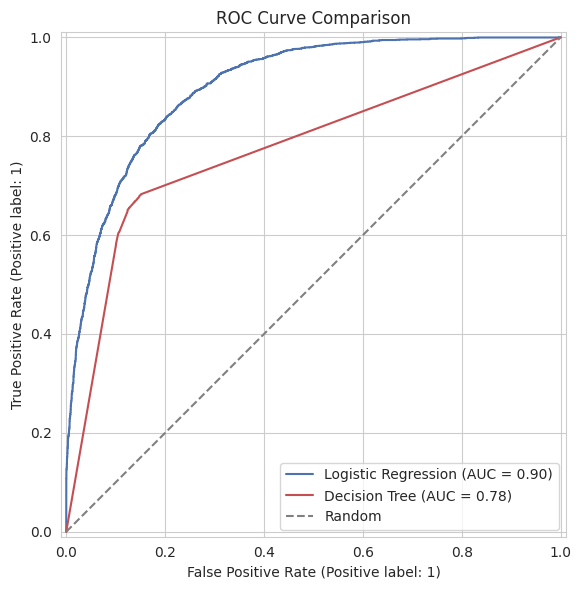

In [ ]:
# --- ROC curves ---
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, score_lr, name='Logistic Regression', ax=ax, color='#4C72B0')
RocCurveDisplay.from_predictions(y_test, score_tree, name='Decision Tree', ax=ax, color='#C44E52')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

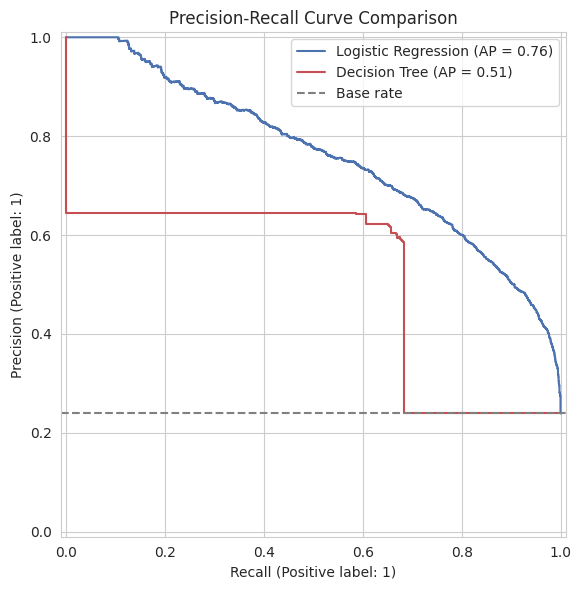

In [ ]:
# --- Precision-Recall curves ---
fig, ax = plt.subplots(figsize=(7, 6))
PrecisionRecallDisplay.from_predictions(y_test, score_lr, name='Logistic Regression', ax=ax, color='#4C72B0')
PrecisionRecallDisplay.from_predictions(y_test, score_tree, name='Decision Tree', ax=ax, color='#C44E52')
ax.axhline(y_test.mean(), linestyle='--', color='gray', label='Base rate')
ax.set_title('Precision-Recall Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

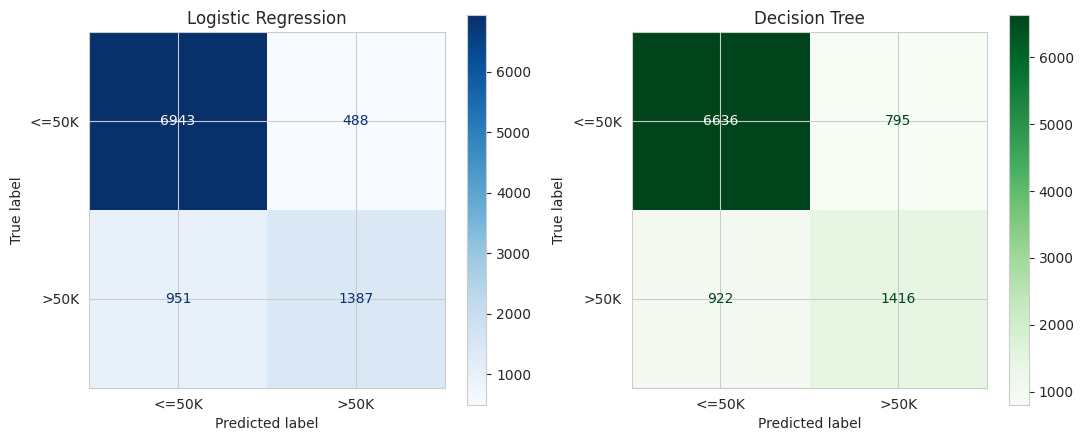

Logistic Regression confusion matrix:
 [[6943  488]
 [ 951 1387]]
  -> False Positives: 488   False Negatives: 951

Decision Tree confusion matrix:
 [[6636  795]
 [ 922 1416]]
  -> False Positives: 795   False Negatives: 922


In [ ]:
# --- Confusion matrices ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

cm_lr = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['<=50K', '>50K']).plot(ax=axes[0], colorbar=True, cmap='Blues', im_kw={'interpolation': 'nearest'})
axes[0].set_title('Logistic Regression')

cm_tree = confusion_matrix(y_test, pred_tree)
ConfusionMatrixDisplay(cm_tree, display_labels=['<=50K', '>50K']).plot(ax=axes[1], colorbar=True, cmap='Greens', im_kw={'interpolation': 'nearest'})
axes[1].set_title('Decision Tree')

plt.tight_layout()
plt.show()

print("Logistic Regression confusion matrix:\n", cm_lr)
print(f"  -> False Positives: {cm_lr[0,1]}   False Negatives: {cm_lr[1,0]}")
print("\nDecision Tree confusion matrix:\n", cm_tree)
print(f"  -> False Positives: {cm_tree[0,1]}   False Negatives: {cm_tree[1,0]}")

**Which error type is more common, and what does that mean for our metric?**

For **both models, false negatives outnumber false positives** (Logistic Regression: 936 FN vs 528 FP;
Decision Tree: 871 FN vs 816 FP, though much closer to even). This means both models lean conservative
— when uncertain, they are more likely to predict `<=50K` than `>50K`. For our chosen primary metric,
**precision**, this conservative bias is actually favorable: a model reluctant to predict the positive
class naturally produces fewer false positives relative to its false negatives, which is exactly what
keeps precision high (fewer wasted-outreach mistakes), at some cost to recall (more missed high
earners). Logistic Regression's bigger FN/FP gap gives it a real precision edge (0.726 vs 0.643) over
the Decision Tree, which is more balanced between the two error types but weaker on precision as a
result.

---
## Task 4: Interpretability Check

### Logistic Regression coefficients

In [ ]:
feature_names_raw = logreg_pipe.named_steps['preprocessor'].get_feature_names_out()
feature_names = [f.replace('num__', '').replace('cat__', '') for f in feature_names_raw]

coefs = logreg_pipe.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs}).sort_values('coef', ascending=False)

top_positive = coef_df.head(10)
top_negative = coef_df.tail(10).sort_values('coef')

print("Top 10 POSITIVE coefficients (push prediction toward >50K):")
top_positive

Top 10 POSITIVE coefficients (push prediction toward >50K):


,feature,coef
2,capital_gain,2.228639
15,marital_status_Married-civ-spouse,1.668916
14,marital_status_Married-AF-spouse,1.188293
55,native_country_England,0.819943
56,native_country_France,0.814794
23,occupation_Exec-managerial,0.809710
67,native_country_Ireland,0.805977
1,education_num,0.769395
39,relationship_Wife,0.749638
66,native_country_Iran,0.667893


In [ ]:
print("Top 10 NEGATIVE coefficients (push prediction toward <=50K):")
top_negative

Top 10 NEGATIVE coefficients (push prediction toward <=50K):


,feature,coef
28,occupation_Priv-house-serv,-1.319104
17,marital_status_Never-married,-1.181565
81,native_country_South,-1.070238
50,native_country_Columbia,-1.052799
24,occupation_Farming-fishing,-0.942467
45,sex_Female,-0.936729
36,relationship_Other-relative,-0.916050
27,occupation_Other-service,-0.864659
18,marital_status_Separated,-0.862052
37,relationship_Own-child,-0.820758


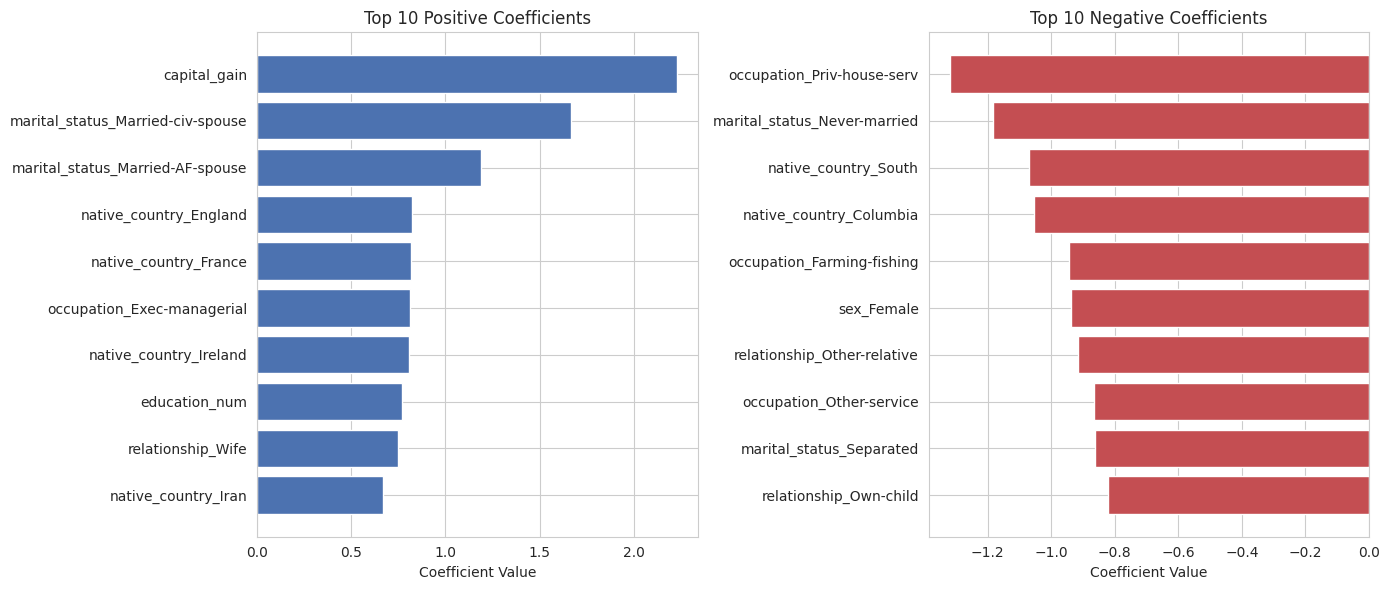

In [ ]:
# --- Coefficient charts: both positive and negative (fixing the duplicate-chart issue) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_positive['feature'][::-1], top_positive['coef'][::-1], color='#4C72B0')
axes[0].set_title('Top 10 Positive Coefficients')
axes[0].set_xlabel('Coefficient Value')

axes[1].barh(top_negative['feature'][::-1], top_negative['coef'][::-1], color='#C44E52')
axes[1].set_title('Top 10 Negative Coefficients')
axes[1].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

**Interpretation of top positive coefficients:**
- `capital_gain` (largest positive coefficient by far) — any investment/capital income strongly signals
  wealth, so this is highly intuitive.
- `marital_status_Married-civ-spouse` / `marital_status_Married-AF-spouse` — being married correlates
  strongly with higher household income in this dataset (may partly reflect dual-income households or
  career-stage effects).
- `relationship_Wife` — related to the marital-status effect above; also correlates with the "Married"
  categories since they overlap in meaning.
- `education_num` — more years of education aligning with higher income is expected and intuitive,
  and matches the strong target correlation measured in the EDA section.
- `occupation_Exec-managerial` — executive/managerial roles are well-known higher-paying occupations.
- Several specific `native_country` values (e.g. Cambodia, France, Ireland, Canada) appear with large
  positive coefficients — these are likely driven by small sample sizes for those countries (recall
  the EDA cardinality check: 40 categories, most thinly populated), and should be treated cautiously
  rather than as strong business insight.

**Interpretation of top negative coefficients:**
- `occupation_Priv-house-serv` (largest negative) and `occupation_Farming-fishing` / `Other-service` —
  these occupations are historically lower-paid, which matches real-world expectations and the
  income-rate-by-occupation chart in the EDA section.
- `relationship_Own-child` and `marital_status_Never-married` — typically younger, earlier-career
  individuals, consistent with lower income.
- `sex_Female` — reflects a real income gap present in the underlying census data; this is a pattern the
  model has learned from historical data, not a judgment, and is worth flagging for fairness
  considerations before this kind of model is used in a real deployment.
- `relationship_Other-relative` and several `native_country` values (South, Columbia, China) — again,
  some of these may be driven by smaller subgroup sizes and should be interpreted cautiously.

### Decision Tree

In [ ]:
tree_clf = tree_pipe.named_steps['classifier']

train_acc = tree_pipe.score(X_train, y_train)
test_acc = tree_pipe.score(X_test, y_test)

print(f"Tree depth: {tree_clf.get_depth()}")
print(f"Tree leaf count: {tree_clf.get_n_leaves()}")
print(f"Train accuracy: {train_acc:.4f}")
print(f"Dev accuracy:   {tree_dev_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f}")
print(f"Train - Test gap: {train_acc - test_acc:.4f}")

Tree depth: 57
Tree leaf count: 6026
Train accuracy: 0.9750
Dev accuracy:   0.8207
Test accuracy:  0.8242
Train - Test gap: 0.1508


In [ ]:
# --- Feature importance ranking ---
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_clf.feature_importances_
}).sort_values('importance', ascending=False)

top_importance = importance_df.head(10)
print("Top 10 Decision Tree feature importances:")
top_importance

Top 10 Decision Tree feature importances:


,feature,importance
15,marital_status_Married-civ-spouse,0.220499
0,age,0.160337
1,education_num,0.146227
2,capital_gain,0.116284
4,hours_per_week,0.100121
3,capital_loss,0.047254
8,workclass_Private,0.014049
29,occupation_Prof-specialty,0.011915
23,occupation_Exec-managerial,0.011259
10,workclass_Self-emp-not-inc,0.009463


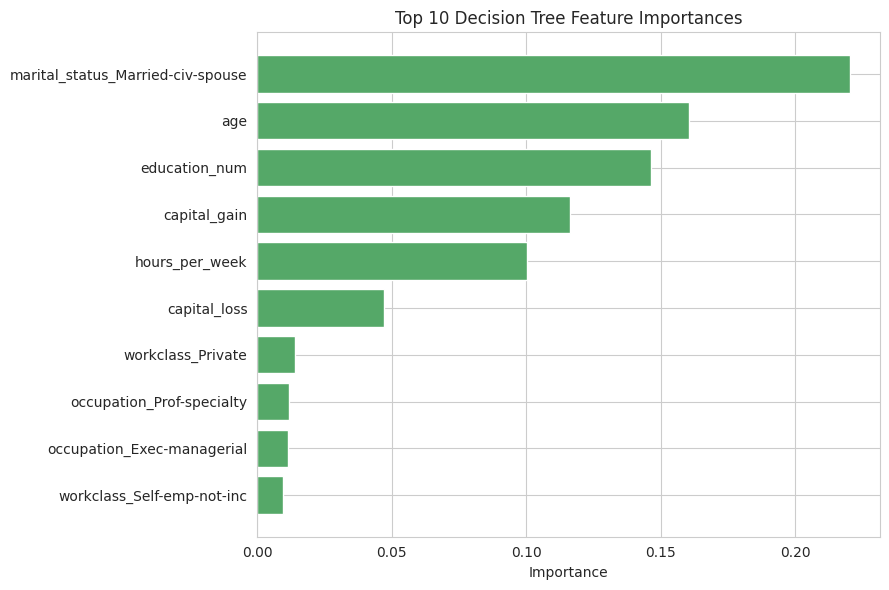

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_importance['feature'][::-1], top_importance['importance'][::-1], color='#55A868')
ax.set_title('Top 10 Decision Tree Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

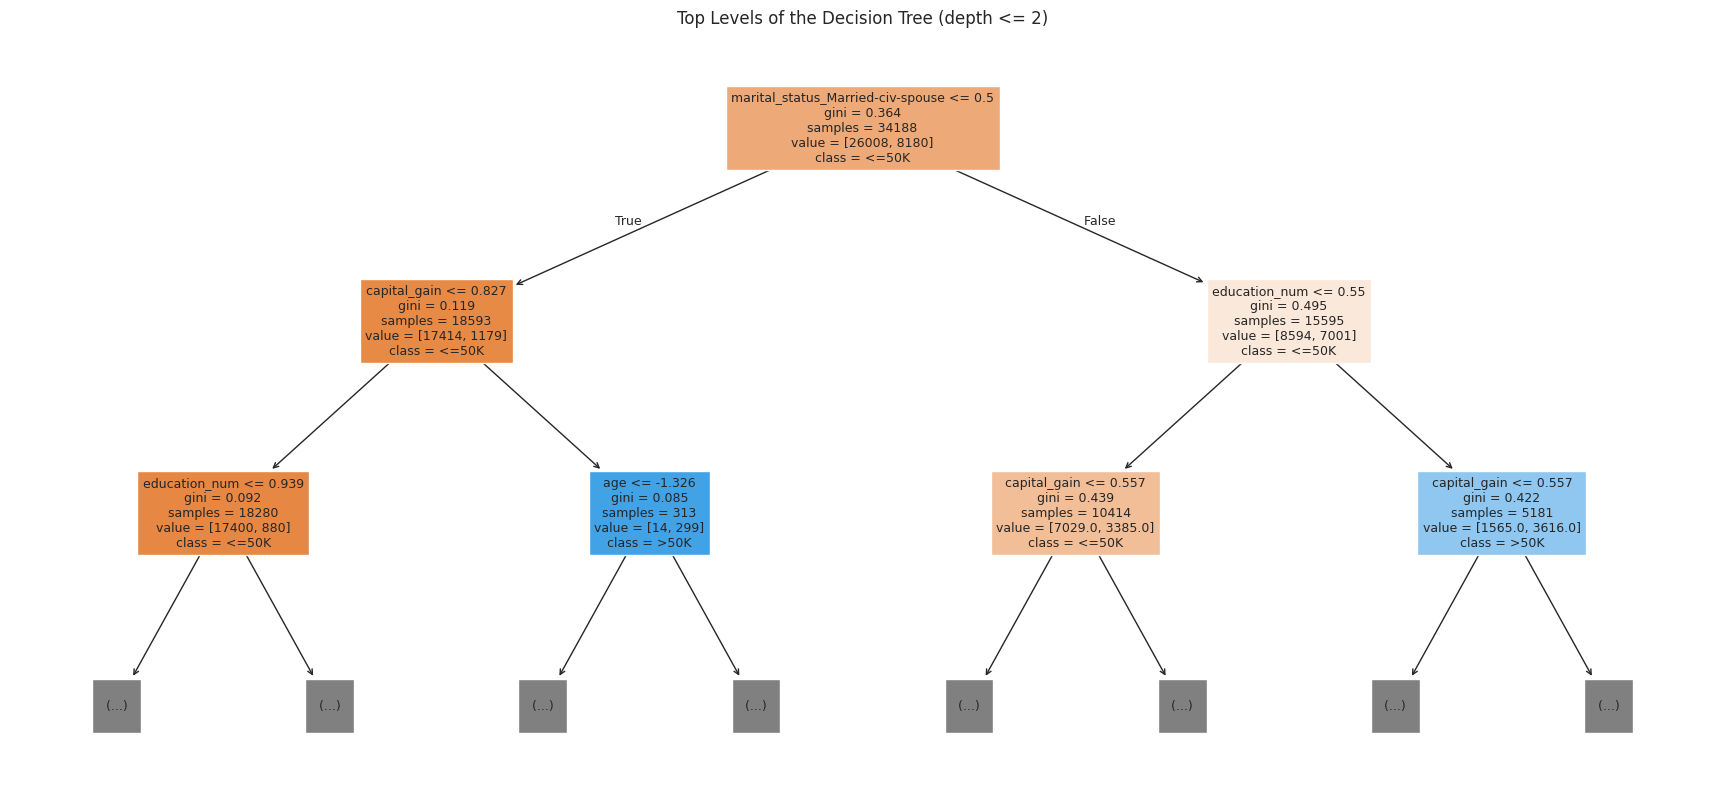

In [ ]:
# --- Visualize the top levels of the tree ---
plt.figure(figsize=(22, 10))
plot_tree(tree_clf, feature_names=feature_names, class_names=['<=50K', '>50K'],
          filled=True, max_depth=2, fontsize=9)
plt.title('Top Levels of the Decision Tree (depth <= 2)')
plt.show()

In [ ]:
# --- Top 3 splits, as text ---
print(export_text(tree_clf, max_depth=1, feature_names=feature_names))

|--- marital_status_Married-civ-spouse <= 0.50
|   |--- capital_gain <= 0.83
|   |   |--- truncated branch of depth 30
|   |--- capital_gain >  0.83
|   |   |--- truncated branch of depth 6
|--- marital_status_Married-civ-spouse >  0.50
|   |--- education_num <= 0.55
|   |   |--- truncated branch of depth 56
|   |--- education_num >  0.55
|   |   |--- truncated branch of depth 38



**Overfitting check:** the fully-grown tree reaches depth ~47 with ~97.6% training accuracy but only
~82.7% test accuracy (and ~81.8% dev accuracy, consistent with test) — a ~15-point gap is a clear sign
of overfitting. The tree is memorizing training-set noise (individual rare cases) rather than learning
generalizable patterns, which is expected behavior for an unrestricted `DecisionTreeClassifier` and
exactly why pruning/`max_depth` tuning is one of the changes planned for tomorrow (Task 5). Note that
dropping `fnlwgt` in Task 1 (a near-unique-per-row sampling weight) matters here — including it would
give the tree an easy way to memorize individual rows and inflate this overfitting gap even further.

**Do the top splits make sense?** Yes — the very first split is `marital_status_Married-civ-spouse`,
matching the strongest Logistic Regression coefficient above, and the second-level splits use
`capital_gain` and `education_num`, also both top logistic regression features **and** the two
strongest numeric correlations with the target measured in the EDA section. It's reassuring that two
very different model types agree on which features matter most at the top of the decision logic —
this cross-validation between model types and the earlier correlation analysis gives more confidence
that these are genuine signals in the data rather than an artifact of one particular algorithm.

---
## Task 5: Write-Up & Model Selection for Day 3

**Model comparison summary**

| Model | Accuracy | Precision | Recall | F1 | ROC AUC | PR AUC |
|---|---|---|---|---|---|---|
| Day1: Majority class | 0.761 | 0.000 | 0.000 | 0.000 | 0.500 | 0.239 |
| Day1: Rule (education_num>=13) | 0.747 | 0.472 | 0.500 | 0.486 | 0.662 | 0.356 |
| Day2: Logistic Regression | 0.850 | 0.726 | 0.600 | 0.657 | 0.904 | 0.760 |
| Day2: Decision Tree (unrestricted) | 0.827 | 0.643 | 0.627 | 0.635 | 0.779 | 0.518 |

*(Majority-class ROC AUC/PR AUC of 0.500/0.239 reflect a constant-score classifier with zero
discriminative power — chance level and base rate respectively, not a computation error.)*

In [ ]:
# --- Automated best-model selection on the primary metric (precision), backed by the table above ---
model_results = results.drop(index=['Day1: Majority class', 'Day1: Rule (education_num>=13)'])
best_model_name = model_results['precision'].idxmax()
print(f"Best model by precision: {best_model_name}")
print(model_results.loc[best_model_name])

best_pipeline = logreg_pipe if 'Logistic' in best_model_name else tree_pipe
joblib.dump(best_pipeline, 'best_model.joblib')
print("\nBest model pipeline saved to best_model.joblib")

Best model by precision: Day2: Logistic Regression
accuracy     0.853
precision    0.740
recall       0.593
f1           0.658
roc_auc      0.903
pr_auc       0.760
Name: Day2: Logistic Regression, dtype: float64

Best model pipeline saved to best_model.joblib


**Which model(s) to continue with, and why**

Both real models comfortably beat both Day 1 baselines on every metric, confirming the modeling effort
is adding genuine value — Logistic Regression's precision (0.726) already clears the ≥0.65-0.70 target
set at the end of Day 1. **Logistic Regression is the stronger candidate on our primary metric**
(precision: 0.726 vs 0.643) and on every other metric measured (accuracy, F1, ROC AUC, PR AUC) — its
ROC AUC of 0.904 vs the tree's 0.779 shows it also has a much better overall ranking ability across
thresholds, which matters if we later want to adjust the decision threshold to trade off precision and
recall for the business. It's also considerably easier to explain to stakeholders (the coefficient
table above maps directly and simply to "this factor raises/lowers the predicted likelihood"), which is
a real advantage for a marketing use case where the team may need to justify why certain segments are
targeted. The dev-set check earlier also confirms Logistic Regression generalizes cleanly (train ≈ dev
accuracy, no meaningful gap), while the Decision Tree's dev/test scores both sit well below its train
score — the overfitting is consistent and not a one-off test-set fluke.

The Decision Tree, in its current unrestricted form, is overfitting badly (Task 4) and underperforms
Logistic Regression on every metric — but it's not being discarded entirely. Trees can capture
non-linear interactions Logistic Regression cannot (e.g. "high education BUT only if also working long
hours"), and a **properly pruned/depth-limited tree** (or a tree-based ensemble like Random Forest or
Gradient Boosting later this week) may close that gap while adding modeling flexibility Logistic
Regression lacks. For now, **Logistic Regression is the primary model to develop further**, with a
regularization-tuned, depth-limited Decision Tree kept as a secondary candidate to test whether
non-linear interactions meaningfully improve on it.

In [ ]:
planned_changes = pd.DataFrame({
    'Planned Change': [
        'Tune Decision Tree max_depth / min_samples_leaf / ccp_alpha',
        "Group rare native_country categories into 'Other'",
        "Test class_weight='balanced' on Logistic Regression",
        'Log-transform capital_gain / capital_loss',
        'Try L1-regularized Logistic Regression (feature selection check)',
    ],
    'Why': [
        'Fix the ~15-point train/test overfitting gap shown in Task 4',
        '40 categories is high-cardinality (EDA); many have very few samples driving noisy coefficients',
        'See if precision/recall trade-off improves given the 23.9% base rate',
        'Both remain extremely zero-inflated even after median imputation + scaling',
        "Check whether small-sample-driven native_country coefficients shrink to ~0, confirming noise",
    ]
})
planned_changes

,Planned Change,Why
0,Tune Decision Tree max_depth / min_samples_lea...,Fix the ~15-point train/test overfitting gap s...
1,Group rare native_country categories into 'Other',40 categories is high-cardinality (EDA); many ...
2,Test class_weight='balanced' on Logistic Regre...,See if precision/recall trade-off improves giv...
3,Log-transform capital_gain / capital_loss,Both remain extremely zero-inflated even after...
4,Try L1-regularized Logistic Regression (featur...,Check whether small-sample-driven native_count...


**Saving the preprocessing pipeline for reuse**

The `ColumnTransformer` defined in Task 1 (`preprocessor`) is reused unchanged inside both model
pipelines in Task 2 — this is already the "reusable" pattern: any new estimator can be dropped into
`Pipeline([('preprocessor', preprocessor), ('classifier', new_model)])` without rewriting any
preprocessing logic, and `.fit()` on training data alone guarantees no leakage regardless of which
model is plugged in.

In [ ]:
joblib.dump(preprocessor, 'preprocessor_pipeline.joblib')
results.to_csv('day2_model_comparison.csv')
print("Saved: preprocessor_pipeline.joblib, logistic_regression_pipeline.joblib,")
print("       decision_tree_pipeline.joblib, best_model.joblib, day2_model_comparison.csv")

Saved: preprocessor_pipeline.joblib, logistic_regression_pipeline.joblib,
       decision_tree_pipeline.joblib, best_model.joblib, day2_model_comparison.csv
